In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path
import functools

import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
code_dir = f'{os.getenv('HOME')}/cai-dr2-clustering-products/clustering_statistics/'
sys.path.insert(0,code_dir)
import tools
import plotting_tools

In [3]:
plot_dir = Path('_plots')
plot_dir.mkdir(exist_ok=True)
ext = 'png'

In [4]:
# !ls /global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base/holi-v3-altmtl/

# Check dubious realizations (Holi v3)

In [7]:
def custom_get_stats_fn(get_stats_fn, imock=None, include_dubious=False, **kwargs):
    # custom function to load stats
    if imock is None:
        return get_stats_fn(**kwargs)
    else:
        if imock == '*':
            fns = [get_stats_fn(imock=jmock, **kwargs) for jmock in range(2001)] 
        else:
            fns = [get_stats_fn(imock=imock, **kwargs)]    
        if include_dubious:
            fns += [str(fn).replace('mock','dubious_mock_') for fn in fns]
        fns = [fn for fn in fns if os.path.exists(fn)]
        # sorting to make it easier to keep track
        # fns = sorted([str(fn).replace('dubious_mock_','mock') for fn in fns]) 
        return fns
        
# example:
# stats_kws = dict(stats_dir=stats_dir, project=project, kind='mesh3_spectrum', basis='sugiyama-diagonal', 
#                  version=version, tracer=tracer, zrange=zrange, weight='default-FKP', region=region)

# all_mocks = custom_get_stats_fn(get_stats_fn=functools.partial(tools.get_stats_fn, **stats_kws), imock='*', use_dubious=True)
# len(all_mocks)

In [8]:
stats_dir = Path(str(tools.base_stats_dir).replace('global','dvs_ro'))
analysis  = 'full_shape'
project   = f'{analysis}/base'
version   = 'holi-v3-altmtl'

region = 'GCcomb'
tracer = 'QSO'
tracer = tools.get_full_tracer(tracer, version=version)
zrange = (0.8,2.1)

In [9]:
# example:
stats_kws = dict(stats_dir=stats_dir, project=project, kind='mesh3_spectrum', basis='sugiyama-diagonal', 
                 version=version, tracer=tracer, zrange=zrange, weight='default-FKP', region=region)

# this will find all mock fns (including for dubious realizations)
fns = custom_get_stats_fn(get_stats_fn=functools.partial(tools.get_stats_fn, **stats_kws), imock='*', include_dubious=True) 
print(tracer, version, zrange, 'mesh3_spectrum-sugiyama-diagonal',len(fns))
stats = list(map(types.read, fns))
mean  = types.mean(stats)
cov   = types.cov(stats).at.observable.match(mean)

# now remove dubious identifier from fn
fns = [str(fn).replace('dubious_mock_','mock') for fn in fns]

QSO holi-v3-altmtl (0.8, 2.1) mesh3_spectrum-sugiyama-diagonal 1000


141 / 1000 are over threshold (>2.5e+06)


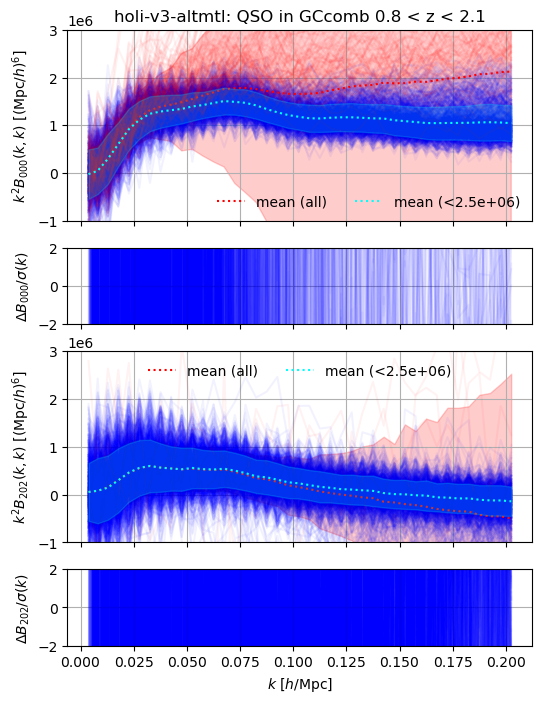

In [10]:
lw = 2
alpha=0.05
ylim=(-1e6, 3e6)
ylim_subpanel=(-2., 2.)
scaling = 'kpk'
k_exp = 1 if scaling == 'kpk' else 0
ells4bk=((0,0,0),(2,0,2))
zranges = [zrange]

# save mocks with power under some aribitrary threshold
threshold = 2.5e6
good_stats = [] 
bad_imocks = []
good_imocks = []
for i, stat in enumerate(stats):
    pole = stat.get(ells4bk[0])
    x = pole.coords('k')[..., 0]
    value = (x**2)**k_exp * pole.value().real
    # if value over threshold its bad, good otherwise
    if np.any(value > threshold):
        bad_imocks.append(int(str(fns[i]).split('/')[-2].replace('mock','')))
    else:
        good_imocks.append(int(str(fns[i]).split('/')[-2].replace('mock','')))
        good_stats.append(stat)
# check the good_imocks are truly good (since I am not sure if the indexing is conserved between fns and stats)
for imock in good_imocks:
    # fn = tools.get_stats_fn(region=region, imock=imock, **stats_kws)
    fn = custom_get_stats_fn(get_stats_fn=functools.partial(tools.get_stats_fn, **stats_kws), 
                             imock=imock, include_dubious=True)[0]
    stat = types.read(fn)
    pole = stat.get(ells4bk[0])
    x = pole.coords('k')[..., 0]
    value = (x**2)**k_exp * pole.value().real
    if np.any(value > threshold): 
        # if value over threshold its bad, good otherwise
        print(value)
        raise ValueError('Found bad mock within good mocks')
        
print(f'{len(stats)-len(good_stats)} / {len(stats)} are over threshold (>{threshold:1.1e})')
good_mean = types.mean(good_stats)
good_cov  = types.cov(good_stats).at.observable.match(good_mean)

nrows  = len(ells4bk) * 2
ncols  = len(zranges)
figure = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * len(ells4bk)), sharex='col', gridspec_kw={'height_ratios': [2.5, 1] * len(ells4bk)})
fig, axes = figure
ax_col = 0
if axes.ndim == 1:
    lax = axes
else:
    lax = axes[:, ax_col]
lax[0].set_title(f'{version}: {tracer} in {region} {zrange[0]:.1f} < z < {zrange[1]:.1f}')

for ill, ell in enumerate(ells4bk):
    ax = lax[2 * ill]
    if scaling == 'kpk':
        ax.set_ylabel(rf'$k^2 B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^6$]')
    if scaling == 'loglog':
        ax.set_ylabel(rf'$B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^4$]')
        ax.set_yscale('log')
        ax.set_xscale('log')

    #plot mean using all the mocks
    pole = mean.get(ell)
    x = pole.coords('k')[..., 0]
    value = (x**2)**k_exp * pole.value().real
    std = (x**2)**k_exp * cov.at.observable.get(ell).std().real
    ax.fill_between(x, value - std, value + std, color='r', alpha=0.2)
    ax.plot(x, value, color='r',zorder=4,linestyle=':',label='mean (all)')
       
    # good_stats = []  # save mocks with power under some aribitrary threshold
    ax.set_ylim(*ylim)
    for i, stat in enumerate(stats):
        if ell not in stat.ells: continue
        pole = stat.get(ell)
        x = pole.coords('k')[..., 0]
        value = (x**2)**k_exp * pole.value().real
        # if value over threshold paint red, blue otherwise
        if np.any(value > threshold):
            ax.plot(x, value, color='r', alpha=alpha)
        else:
            # good_stats.append(stat)
            ax.plot(x, value, color='b', alpha=alpha)

    # now plot mean and cov using mocks with power under some aribitrary threshold 
    pole = good_mean.get(ell)
    x = pole.coords('k')[..., 0]
    value = (x**2)**k_exp * pole.value().real
    std = (x**2)**k_exp * good_cov.at.observable.get(ell).std().real
    ax.fill_between(x, value - std, value + std, color='cyan', alpha=0.2,zorder=4)
    ax.plot(x, value, color='cyan',zorder=5,linestyle=':',label=f'mean (<{threshold:1.1e})')

    ax.legend(frameon=False, ncol=2)
        
    ax.grid(True)
    ax = lax[2 * ill + 1]
    ax.set_ylabel(rf'$\Delta B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}} / \sigma(k)$')
    ax.grid(True)
    ax.set_ylim(*ylim_subpanel)
    for i, stat in enumerate(stats):
        pole = stat.get(ell)
        x = pole.coords('k')[..., 0]
        ax.plot(x, (pole.value() - mean.get(ell).value()).real / std, color='b', alpha=alpha)
lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
# figure[0].savefig(plot_dir / 'checks_bk_QSO.png', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()

In [11]:
# save .txt with the bad mocks
print(len(bad_imocks), bad_imocks)
# np.savetxt('../helper_scripts/dubious_holi-v3-altmtl.txt',bad_imocks,fmt='%i')

141 [2, 5, 8, 9, 17, 26, 34, 47, 50, 51, 54, 62, 66, 71, 73, 76, 78, 97, 106, 114, 140, 142, 146, 148, 149, 152, 155, 163, 176, 184, 191, 194, 202, 208, 234, 248, 260, 264, 269, 296, 298, 299, 320, 326, 330, 331, 337, 349, 358, 371, 376, 378, 379, 384, 389, 391, 392, 408, 409, 423, 425, 429, 430, 437, 438, 444, 447, 448, 452, 458, 473, 477, 487, 512, 515, 522, 530, 531, 532, 542, 553, 562, 566, 571, 591, 595, 597, 609, 611, 623, 624, 625, 634, 637, 638, 643, 644, 649, 655, 657, 671, 679, 682, 690, 693, 698, 699, 704, 707, 713, 716, 718, 727, 741, 766, 770, 776, 784, 788, 802, 815, 824, 835, 846, 850, 864, 867, 879, 882, 893, 903, 919, 923, 928, 932, 951, 953, 971, 977, 982, 983]


In [12]:
# generate list of good measurements to use for covariance estimation using holi-v3-altmtl
versions = ['holi-v3-altmtl']
_exists = []
for itracer in ['LRG']:
    for version in versions:
        exists, missing = tools.checks_if_exists_and_readable(get_fn=functools.partial(tools.get_catalog_fn, tracer=itracer[0] if isinstance(itracer, (list, tuple)) else itracer,
                                                                                       region='NGC', version=version), test_if_readable=False, imock=np.arange(1500))[:2]
        _exists.append(exists)
        catalog_imocks = exists[1]['imock']
        print(len(catalog_imocks))
        print()
# We find the following realizations to be significant outliers.
bad_imocks = np.loadtxt('../helper_scripts/dubious_holi-v3-altmtl.txt', dtype=int)

# then the realizations to use for covaraince estimation are 
imocks = np.array([int(i) for i in _exists[0][1]['imock']])
imocks = imocks[~np.isin(imocks,bad_imocks)]
print(len(imocks))

# np.savetxt('../helper_scripts/holi-v3-altmtl_dark-time_imocks_for_covariance.txt',imocks,fmt='%i')

1000

859


In [13]:
# now using the good_imocks list idendified above
stats_kws = dict(stats_dir=stats_dir, project=project, kind='mesh2_spectrum', 
                 version=version, tracer=tracer, zrange=zrange, weight='default-FKP')

# fns = tools.get_stats_fn(region=region, imock='*', **stats_kws)
fns = custom_get_stats_fn(get_stats_fn=functools.partial(tools.get_stats_fn, region=region, **stats_kws), imock='*', include_dubious=True) 
print(tracer, version, zrange, 'mesh2_spectrum',len(fns))
stats = list(map(types.read, fns))
mean  = types.mean(stats)
cov   = types.cov(stats).at.observable.match(mean)

fns = [tools.get_stats_fn(region=region, imock=imock, **stats_kws) for imock in good_imocks]
print(tracer, version, zrange, 'mesh2_spectrum',len(fns))
good_stats = list(map(types.read, fns))
good_mean  = types.mean(good_stats)
good_cov   = types.cov(good_stats).at.observable.match(good_mean)

QSO holi-v3-altmtl (0.8, 2.1) mesh2_spectrum 1000
QSO holi-v3-altmtl (0.8, 2.1) mesh2_spectrum 859


In [14]:
fns = [tools.get_stats_fn(region=region, imock=imock, **stats_kws) for imock in bad_imocks]
fns = [str(fn).replace('mock','dubious_mock_') for fn in fns]
print(tracer, version, zrange, 'mesh2_spectrum',len(fns))
bad_stats = list(map(types.read, fns))

QSO holi-v3-altmtl (0.8, 2.1) mesh2_spectrum 141


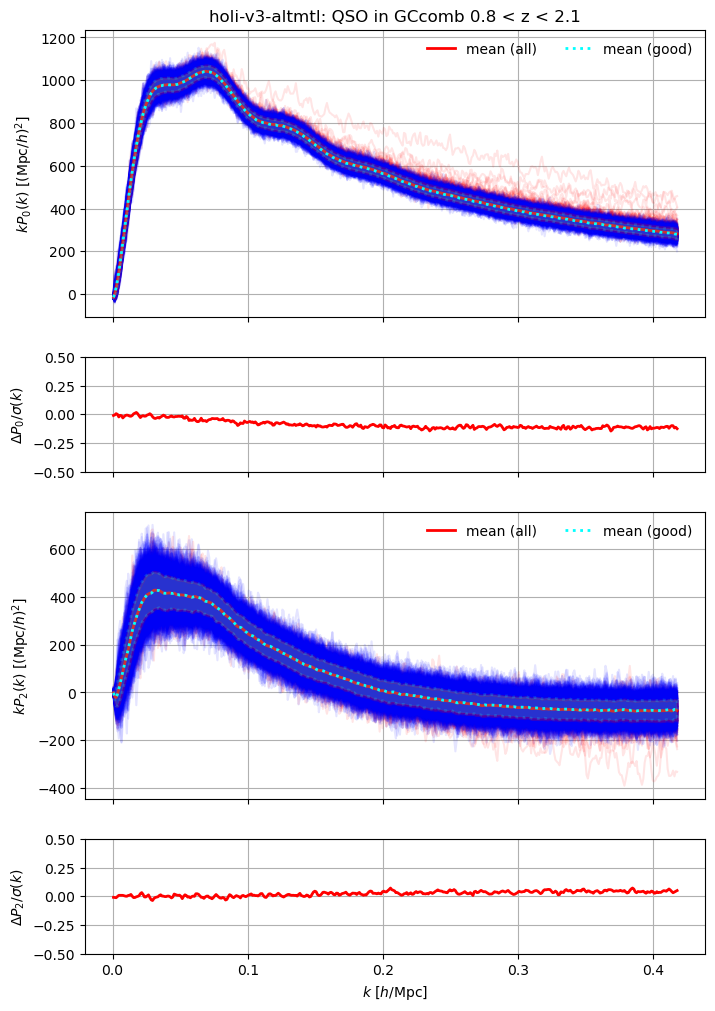

In [15]:
lw = 2
alpha=0.1
ylim=(-1e6, 3e6)
ylim_subpanel=(-.5, .5)
scaling = 'kpk'
k_exp = 1 if scaling == 'kpk' else 0
ells4pk=(0,2)
zranges = [zrange]

nrows  = len(ells4pk) * 2
ncols  = len(zranges)
figure = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6 * len(ells4pk)), sharex='col', 
                      gridspec_kw={'height_ratios': [2.5, 1] * len(ells4pk)})
# figure = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * len(ells4pk)), sharex='col')
fig, axes = figure
ax_col = 0
if axes.ndim == 1:
    lax = axes
else:
    lax = axes[:, ax_col]
lax[0].set_title(f'{version}: {tracer} in {region} {zrange[0]:.1f} < z < {zrange[1]:.1f}')

for ill, ell in enumerate(ells4pk):
    ax = lax[2 * ill]
    # ax = lax[ill]
    if scaling == 'kpk':
        ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
    if scaling == 'loglog':
        ax.set_ylabel(rf'$P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^3$]')
        ax.set_yscale('log')
        ax.set_xscale('log')
       
    # ax.set_ylim(*ylim)
    for i, stat in enumerate(bad_stats):
        if ell not in stat.ells: continue
        pole = stat.get(ell)
        x = pole.coords('k')
        value = x**k_exp * pole.value().real
        ax.plot(x, value, color='r', alpha=alpha)
    
    for i, stat in enumerate(good_stats):
        if ell not in stat.ells: continue
        pole = stat.get(ell)
        x = pole.coords('k')
        value = x**k_exp * pole.value().real
        ax.plot(x, value, color='b', alpha=alpha)

    #plot mean using all the mocks
    pole = bad_pole = mean.get(ell)
    x = pole.coords('k')
    value = x**k_exp * pole.value().real
    std = x**k_exp * cov.at.observable.get(ell).std().real
    ax.fill_between(x, value - std, value + std, color='r', alpha=0.2,lw=lw, zorder=4)
    ax.plot(x, value, color='r',zorder=4,linestyle='-',label='mean (all)',lw=lw)
    
    # now plot mean and cov using mocks with power under some aribitrary threshold 
    pole = good_pole = good_mean.get(ell)
    x = pole.coords('k')
    value = x**k_exp * pole.value().real
    std = x**k_exp * good_cov.at.observable.get(ell).std().real
    ax.fill_between(x, value - std, value + std, color='cyan', linestyle=':',lw=lw, alpha=0.2,zorder=5)
    ax.plot(x, value, color='cyan',zorder=5,linestyle=':',label=f'mean (good)',lw=lw)

    ax.legend(frameon=False, ncol=2)

    ax.grid(True)
    ax = lax[2 * ill + 1]
    ax.set_ylabel(rf'$\Delta P_{ell:d} / \sigma(k)$')
    ax.grid(True)
    ax.set_ylim(*ylim_subpanel)
    std = cov.at.observable.get(ell).std().real
    ax.plot(x, (good_pole.value().real - bad_pole.value().real) / std, color='r', ls='-', lw=lw)
    # std = good_cov.at.observable.get(ell).std().real
    # ax.plot(x, (good_pole.value().real - bad_pole.value().real) / std, color='cyan', ls=':', lw=lw)
    
lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
# figure[0].savefig(plot_dir / 'checks_pk_QSO.png', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()